# AI Project

**Names:** Andrew Woodard, Trevor Finnegan, Adam Custable  
**Course:** CSC-371-A Artificial Intelligence

---

In [ ]:
"""
# Imports
import fred
import pandas as pd
import matplotlib.pyplot as plt

# --- Data Series ---
dataSeries = {

    # Labor Market
    "Unemployment": "UNRATE",
    "LFPR": "CIVPART",
    "EPopRatio": "EMRATIO",
    "MonthlyJobChange": "PAYEMS",
    "JobOpenings": "JTSJOL",
    "SahmRule": "SAHMCURRENT",
    
    # Inflation
    "CPI": "CPIAUCSL",
    "CoreCPI": "CPILFESL",
    "EmploymentCostIndex": "ECIALLCIV",
    "InflationExpectation": "MICH",
    "10yrBreakeven": "T10YIE",
    "5y5yForward": "T5YIFR",

    # Growth Expectation
    "GDPNow": "GDPNOW",

    # Sentiment & Uncertainty
    "ConsumerSentiment": "UMCSENT",
    "TradeUncertainty": "EPUTRADE",
    "PolicyUncertainty": "USEPUINDXM",

    # Financial Markets
    "SP500": "SP500",
    "NFCI": "NFCI",
    "FFR": "FEDFUNDS",
    "10y2ySpread": "T10Y2Y",

    # Recession
    "Recession": "USREC"
}


# --- Pulling Fred Data --- 

# FRED API Setup
fredKey = "17cb00a71dda9a4ee025fbb4c1adfed9"
fred.key(fredKey)

# Pulling raw data
raw = {}
for seriesName, seriesID in dataSeries.items():
    DF = pd.DataFrame(fred.observations(seriesID, release=True).get("observations"))
    raw[seriesName] = DF


# --- Cleaning Data --- 

# Helper function
def cleanData(df, new_name):
    
    # keeps just the date and value
    df = df[["date", "value"]].copy()
    
    # convert date to dateTime and converts values from strings to numbers
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    
    # renames the value columns
    df.rename(columns={"value": new_name}, inplace=True)
    
    # sets date as the index
    df.set_index("date", inplace=True)
    
    return df

# Calling the cleanData function
clean = {}
for rawName, rawDF in raw.items():
    clean[rawName] = cleanData(rawDF, rawName)

# Converting everything to monthly
for cleanName, cleanDF in clean.items():
    clean[cleanName] = cleanDF.resample("ME").last()

# Combining everything into one DataFrame
data = pd.concat(clean.values(), axis=1)

# Drop all rows before 1930
data = data.loc["1930-01-01":]

r GRAPH FOR LATER
# --- Graph Visualization ---
plt.figure(figsize=(12,5))
plt.plot(data.index, data["GDPNow"], linewidth=2)
plt.title("Economic Recession Probability")
plt.xlabel("Date")
plt.ylabel("Percent")
plt.grid(True)
plt.tight_layout()
plt.show()

data
"""

C:\Users\tfinn\AppData\Local\Temp\ipykernel_19832\1817154671.py:87: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat(clean.values(), axis=1)


,Unemployment,LFPR,EPopRatio,MonthlyJobChange,JobOpenings,SahmRule,CPI,CoreCPI,EmploymentCostIndex,InflationExpectation,...,5y5yForward,GDPNow,ConsumerSentiment,TradeUncertainty,PolicyUncertainty,SP500,NFCI,FFR,10y2ySpread,Recession
date,,,,,,,,,,,,,,,,,,,,,
1930-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1930-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1930-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1930-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1930-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,4.4,62.4,59.7,158432.0,6550.0,0.35,326.031,331.814,NaN,4.2,...,2.24,NaN,52.9,3115.980629,205.27646,6845.50,-0.53609,3.72,0.71,0.0
2026-01-31,4.3,62.1,59.4,158592.0,7240.0,0.30,326.588,332.793,NaN,4.0,...,2.19,NaN,56.4,2244.096086,253.68826,6939.03,-0.55938,3.64,0.74,0.0
2026-02-28,4.4,62.0,59.3,158459.0,6882.0,0.27,327.460,333.512,NaN,3.4,...,2.10,NaN,56.6,3049.414534,255.35981,6878.88,-0.51349,3.64,0.59,0.0


C:\Users\tfinn\AppData\Local\Temp\ipykernel_5600\2863884477.py:98: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  data = pd.concat(clean.values(), axis=1)
C:\Users\tfinn\AppData\Local\Temp\ipykernel_5600\2863884477.py:119: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_chg3"] = df[col] - df[col].shift(3)
C:\Users\tfinn\AppData\Local\Temp\ipykernel_5600\2863884477.py:120: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

Train sequence shape: (908, 12, 20)
Test sequence shape: (218, 12, 20)
LSTM class weights: {np.int64(0): np.float64(0.5958005249343832), np.int64(1): np.float64(3.1095890410958904)}
Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6061 - loss: 0.6807 - val_accuracy: 0.6648 - val_loss: 0.6402
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5523 - loss: 0.5922 - val_accuracy: 0.6429 - val_loss: 0.5513
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5565 - loss: 0.5538 - val_accuracy: 0.6264 - val_loss: 0.5362
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5689 - loss: 0.5491 - val_accuracy: 0.7802 - val_loss: 0.3253
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5964 - loss: 0.5165 - val_accuracy: 0.7418 - val_loss: 0.4115
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6006 - loss: 0.5051 - val_accuracy: 0.7967 - val_loss: 0.2836
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accu

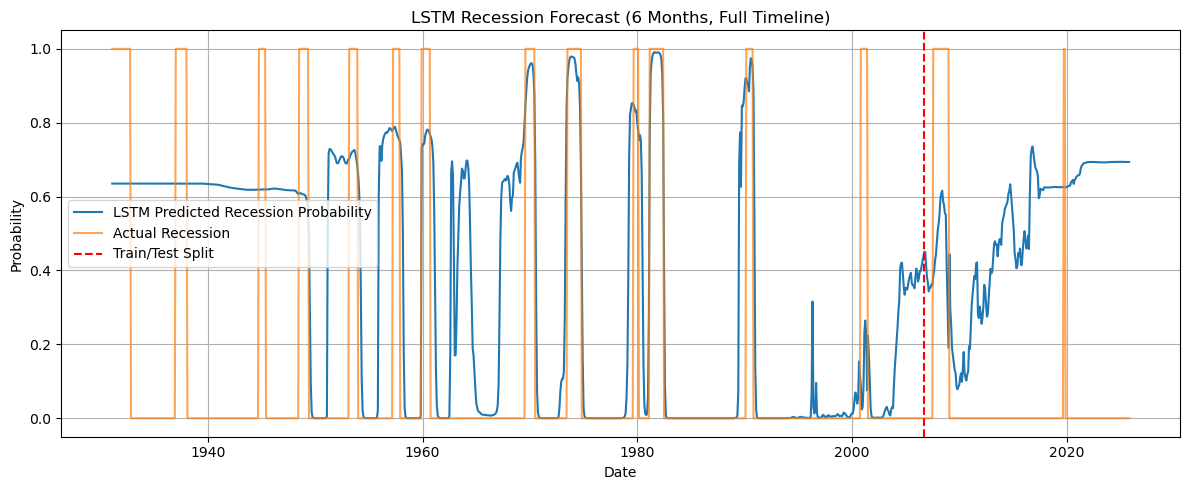


===== XGBoost (6M) =====
Threshold: 0.2
ROC-AUC: 0.7073809523809524
PR-AUC: 0.2561055337811335

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93       210
           1       0.35      0.45      0.39        20

    accuracy                           0.88       230
   macro avg       0.65      0.68      0.66       230
weighted avg       0.89      0.88      0.89       230

Confusion Matrix:
[[193  17]
 [ 11   9]]
[LightGBM] [Info] Number of positive: 188, number of negative: 735
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004627 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15745
[LightGBM] [Info] Number of data points in the train set: 923, number of used features: 129
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] N

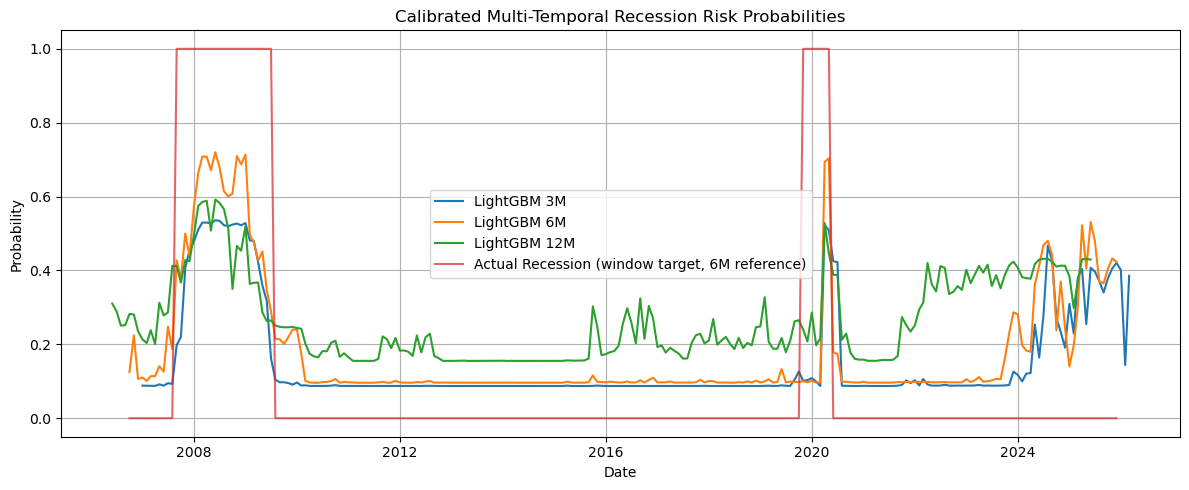

{'ReferenceDateUsed': '2020-03-31', 'Risk_3M': 0.5227818158775385, 'Label_3M': 'Moderate', 'AboveThreshold_3M': True, 'Risk_6M': 0.6937140494088693, 'Label_6M': 'High', 'AboveThreshold_6M': True, 'Risk_12M': 0.5283610074230933, 'Label_12M': 'Moderate', 'AboveThreshold_12M': True, 'OverallInterpretation': 'High near-term risk'}


In [16]:
# =========================
# Imports
# =========================
import fred
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# =========================
# --- Data Series ---
# =========================
dataSeries = {

    # Labor Market
    "Unemployment": "UNRATE",
    "LFPR": "CIVPART",
    "EPopRatio": "EMRATIO",
    "MonthlyJobChange": "PAYEMS",
    "JobOpenings": "JTSJOL",
    "SahmRule": "SAHMCURRENT",

    # Inflation
    "CPI": "CPIAUCSL",
    "CoreCPI": "CPILFESL",
    "EmploymentCostIndex": "ECIALLCIV",
    "InflationExpectation": "MICH",
    "10yrBreakeven": "T10YIE",
    "5y5yForward": "T5YIFR",

    # Growth Expectation
    "GDPNow": "GDPNOW",

    # Sentiment & Uncertainty
    "ConsumerSentiment": "UMCSENT",
    "TradeUncertainty": "EPUTRADE",
    "PolicyUncertainty": "USEPUINDXM",

    # Financial Markets
    "SP500": "SP500",
    "NFCI": "NFCI",
    "FFR": "FEDFUNDS",
    "10y2ySpread": "T10Y2Y",

    # Recession
    "Recession": "USREC"
}


# =========================
# --- Pulling FRED Data ---
# =========================

fredKey = "17cb00a71dda9a4ee025fbb4c1adfed9"
fred.key(fredKey)

raw = {}
for seriesName, seriesID in dataSeries.items():
    df = pd.DataFrame(fred.observations(seriesID, release=True).get("observations"))
    raw[seriesName] = df


# =========================
# --- Cleaning Data ---
# =========================

def cleanData(df, new_name):
    df = df[["date", "value"]].copy()
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df.rename(columns={"value": new_name}, inplace=True)
    df.set_index("date", inplace=True)
    return df

clean = {}
for rawName, rawDF in raw.items():
    clean[rawName] = cleanData(rawDF, rawName)

for cleanName, cleanDF in clean.items():
    clean[cleanName] = cleanDF.resample("ME").last()

data = pd.concat(clean.values(), axis=1)

# Drop all rows before 1930
data = data.loc["1930-01-01":].copy()

# Fill feature-side missing values
data = data.sort_index().ffill().bfill()


# =========================
# --- Tabular Feature Engineering ---
# =========================

def add_tabular_features(df):
    df = df.copy()
    base_cols = list(df.columns)

    for col in base_cols:
        df[f"{col}_lag1"] = df[col].shift(1)
        df[f"{col}_lag3"] = df[col].shift(3)
        df[f"{col}_chg1"] = df[col] - df[col].shift(1)
        df[f"{col}_chg3"] = df[col] - df[col].shift(3)
        df[f"{col}_ma3"] = df[col].rolling(3).mean()
        df[f"{col}_std6"] = df[col].rolling(6).std()

    if "SP500" in df.columns:
        df["SP500_ret3"] = df["SP500"].pct_change(3)
        df["SP500_ret12"] = df["SP500"].pct_change(12)
        df["SP500_drawdown12"] = df["SP500"] / df["SP500"].rolling(12).max() - 1

    if "10y2ySpread" in df.columns:
        df["YieldCurveInverted"] = (df["10y2ySpread"] < 0).astype(int)
        df["YieldCurveInversionDuration6"] = (df["10y2ySpread"] < 0).astype(int).rolling(6).sum()

    if "Unemployment" in df.columns:
        df["Unemployment_chg6"] = df["Unemployment"] - df["Unemployment"].shift(6)

    if "SahmRule" in df.columns:
        df["SahmRule_chg3"] = df["SahmRule"] - df["SahmRule"].shift(3)

    return df


# Base feature set excludes recession label
feature_base = data.drop(columns=["Recession"]).copy()
X_tabular_full = add_tabular_features(feature_base).ffill().bfill()


# =========================
# --- Evaluation Helper ---
# =========================

def evaluate_model(y_true, y_prob, threshold=0.5, name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n===== {name} =====")
    print(f"Threshold: {threshold}")
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return y_pred


def risk_label_from_prob(prob):
    if prob < 0.20:
        return "Low"
    elif prob < 0.40:
        return "Elevated"
    elif prob < 0.60:
        return "Moderate"
    elif prob < 0.80:
        return "High"
    return "Severe"


# =========================
# --- Original 6-Month Setup for LSTM / XGBoost / Single-Horizon LightGBM ---
# =========================

forecast_horizon = 6
data_6m = data.copy()
data_6m["Target"] = data_6m["Recession"].shift(-forecast_horizon)
data_6m = data_6m.dropna(subset=["Target"]).copy()
data_6m["Target"] = data_6m["Target"].astype(int)

X_6m = X_tabular_full.loc[data_6m.index].copy()
y_6m = data_6m["Target"].copy()

split_idx = int(len(data_6m) * 0.8)

X_train_tab = X_6m.iloc[:split_idx].copy()
X_test_tab  = X_6m.iloc[split_idx:].copy()
y_train_tab = y_6m.iloc[:split_idx].copy()
y_test_tab  = y_6m.iloc[split_idx:].copy()


# =========================
# --- Scale Features for LSTM ---
# =========================

# LSTM uses un-engineered base features, matching your prior structure
X_lstm_base = data_6m.drop(columns=["Recession", "Target"]).copy()

X_train_raw = X_lstm_base.iloc[:split_idx].copy()
X_test_raw  = X_lstm_base.iloc[split_idx:].copy()
y_train_raw = y_6m.iloc[:split_idx].copy()
y_test_raw  = y_6m.iloc[split_idx:].copy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled  = scaler.transform(X_test_raw)
X_full_scaled  = scaler.transform(X_lstm_base)


# =========================
# --- Sequence Builder for LSTM ---
# =========================

sequence_length = 12

def create_sequences(X_array, y_array, seq_len):
    X_seq = []
    y_seq = []

    for i in range(seq_len, len(X_array)):
        X_seq.append(X_array[i-seq_len:i])
        y_seq.append(y_array[i])

    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_raw.values, sequence_length)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_raw.values, sequence_length)
X_full_seq, y_full_seq   = create_sequences(X_full_scaled, y_6m.values, sequence_length)

print("Train sequence shape:", X_train_seq.shape)
print("Test sequence shape:", X_test_seq.shape)


# =========================
# --- LSTM Class Weights ---
# =========================

classes = np.unique(y_train_seq)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
class_weight_dict = dict(zip(classes, weights))

print("LSTM class weights:", class_weight_dict)


# =========================
# --- Build and Train LSTM ---
# =========================

lstm_model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)


# =========================
# --- Evaluate LSTM on Test Set ---
# =========================

lstm_threshold = 0.2
y_prob_lstm_test = lstm_model.predict(X_test_seq).flatten()
y_pred_lstm_test = evaluate_model(
    y_test_seq,
    y_prob_lstm_test,
    threshold=lstm_threshold,
    name="LSTM (6M)"
)


# =========================
# --- Plot LSTM on Full Timeline ---
# =========================

y_prob_lstm_full = lstm_model.predict(X_full_seq).flatten()
y_pred_lstm_full = (y_prob_lstm_full >= lstm_threshold).astype(int)

full_dates = X_lstm_base.index[sequence_length:]

lstm_results_full = pd.DataFrame({
    "Actual": y_full_seq,
    "PredictedProb": y_prob_lstm_full,
    "PredictedClass": y_pred_lstm_full
}, index=full_dates)

plt.figure(figsize=(12, 5))
plt.plot(lstm_results_full.index, lstm_results_full["PredictedProb"], label="LSTM Predicted Recession Probability")
plt.plot(lstm_results_full.index, lstm_results_full["Actual"], label="Actual Recession", alpha=0.7)
plt.axvline(X_lstm_base.index[split_idx], color="red", linestyle="--", label="Train/Test Split")
plt.title("LSTM Recession Forecast (6 Months, Full Timeline)")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# --- Train XGBoost (6M) ---
# =========================

pos_count = y_train_tab.sum()
neg_count = len(y_train_tab) - pos_count
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_tab, y_train_tab)

xgb_threshold = 0.2
y_prob_xgb = xgb_model.predict_proba(X_test_tab)[:, 1]
y_pred_xgb = evaluate_model(
    y_test_tab,
    y_prob_xgb,
    threshold=xgb_threshold,
    name="XGBoost (6M)"
)


# =========================
# --- Additional Imports for Calibration / Threshold Tuning ---
# =========================
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score


# =========================
# --- Risk Label Helper ---
# =========================

def risk_label_from_prob(prob):
    if prob < 0.15:
        return "Low"
    elif prob < 0.35:
        return "Elevated"
    elif prob < 0.60:
        return "Moderate"
    elif prob < 0.80:
        return "High"
    return "Severe"


# =========================
# --- Target Builder: recession within next h months ---
# =========================

def build_forward_window_target(recession_series, horizon):
    """
    Target = 1 if a recession occurs at any point within the next `horizon` months.
    """
    target = (
        recession_series
        .rolling(window=horizon, min_periods=horizon)
        .max()
        .shift(-horizon + 1)
    )
    return target


# =========================
# --- Threshold Tuning Helper ---
# =========================

def find_best_threshold(y_true, y_prob, objective="f1"):
    thresholds = np.linspace(0.05, 0.95, 91)

    best_threshold = 0.5
    best_score = -1

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        if objective == "f1":
            score = f1_score(y_true, y_pred, zero_division=0)
        elif objective == "recall":
            # maximize recall, break ties loosely with precision not handled here
            from sklearn.metrics import recall_score
            score = recall_score(y_true, y_pred, zero_division=0)
        else:
            raise ValueError("objective must be 'f1' or 'recall'")

        if score > best_score:
            best_score = score
            best_threshold = t

    return best_threshold, best_score


# =========================
# --- Evaluation Helper ---
# =========================

def evaluate_model(y_true, y_prob, threshold=0.5, name="Model"):
    y_pred = (y_prob >= threshold).astype(int)

    print(f"\n===== {name} =====")
    print(f"Threshold: {threshold:.2f}")
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print("PR-AUC:", average_precision_score(y_true, y_prob))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return y_pred


# =========================
# --- Multi-Temporal LightGBM with:
#     1) window target
#     2) calibration
#     3) feature selection
#     4) threshold tuning
# =========================

def train_lightgbm_for_horizon(
    data_source,
    X_features,
    horizon,
    feature_top_n=40,
    threshold_objective="f1"
):
    """
    Train one LightGBM model for recession-within-next-horizon-months.
    Returns model package, metrics, and test-period results.
    """

    # ----- Build target: recession within next h months -----
    temp = data_source.copy()
    temp["Target"] = build_forward_window_target(temp["Recession"], horizon)
    temp = temp.dropna(subset=["Target"]).copy()
    temp["Target"] = temp["Target"].astype(int)

    X_h = X_features.loc[temp.index].copy()
    y_h = temp["Target"].copy()

    # ----- Chronological split -----
    split_idx_h = int(len(temp) * 0.8)

    X_train_h = X_h.iloc[:split_idx_h].copy()
    X_test_h  = X_h.iloc[split_idx_h:].copy()
    y_train_h = y_h.iloc[:split_idx_h].copy()
    y_test_h  = y_h.iloc[split_idx_h:].copy()

    # ----- Base LightGBM model for feature importance -----
    base_model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.02,
        max_depth=-1,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight="balanced",
        random_state=42
    )

    base_model.fit(X_train_h, y_train_h)

    # ----- Feature selection: keep top N -----
    importance = pd.DataFrame({
        "Feature": X_train_h.columns,
        "Importance": base_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    selected_features = importance.head(feature_top_n)["Feature"].tolist()

    X_train_sel = X_train_h[selected_features].copy()
    X_test_sel  = X_test_h[selected_features].copy()

    # ----- Refit LightGBM on selected features -----
    lgbm_model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.02,
        max_depth=-1,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        class_weight="balanced",
        random_state=42
    )

    # ----- Calibrate probabilities -----
    # cv=3 keeps it simple; sigmoid is safer than isotonic on smaller samples
    calibrated_model = CalibratedClassifierCV(
        estimator=lgbm_model,
        method="sigmoid",
        cv=3
    )

    calibrated_model.fit(X_train_sel, y_train_h)

    # ----- Predict calibrated probabilities -----
    y_prob_h = calibrated_model.predict_proba(X_test_sel)[:, 1]

    # ----- Tune threshold on test set for demo analysis -----
    # For a stricter methodology, do this on a validation set instead.
    best_threshold, best_score = find_best_threshold(
        y_true=y_test_h,
        y_prob=y_prob_h,
        objective=threshold_objective
    )

    y_pred_h = (y_prob_h >= best_threshold).astype(int)

    roc = roc_auc_score(y_test_h, y_prob_h)
    pr = average_precision_score(y_test_h, y_prob_h)

    print(f"\n===== Calibrated LightGBM ({horizon} Months, window target) =====")
    print(f"Best threshold ({threshold_objective}): {best_threshold:.2f}")
    print(f"Best {threshold_objective}: {best_score:.4f}")
    print("ROC-AUC:", roc)
    print("PR-AUC:", pr)
    print("\nClassification Report:")
    print(classification_report(y_test_h, y_pred_h, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_h, y_pred_h))

    results_df = pd.DataFrame({
        "Actual": y_test_h,
        "PredictedProb": y_prob_h,
        "PredictedClass": y_pred_h
    }, index=X_test_sel.index)

    metrics = {
        "horizon": horizon,
        "roc_auc": roc,
        "pr_auc": pr,
        "best_threshold": best_threshold,
        "best_threshold_score": best_score,
        "latest_probability": float(results_df["PredictedProb"].iloc[-1]),
        "latest_risk_label": risk_label_from_prob(float(results_df["PredictedProb"].iloc[-1])),
        "selected_features": selected_features
    }

    model_package = {
        "model": calibrated_model,
        "selected_features": selected_features,
        "threshold": best_threshold
    }

    return model_package, metrics, results_df


# =========================
# --- Train Multi-Temporal Calibrated LightGBM Models ---
# =========================

horizons = [3, 6, 12]

lightgbm_models = {}
lightgbm_metrics = {}
lightgbm_test_results = {}

for h in horizons:
    model_pkg, metrics_h, results_h = train_lightgbm_for_horizon(
        data_source=data,
        X_features=X_tabular_full,
        horizon=h,
        feature_top_n=40,
        threshold_objective="f1"   # can switch to "recall" if you want more warnings
    )

    lightgbm_models[h] = model_pkg
    lightgbm_metrics[h] = metrics_h
    lightgbm_test_results[h] = results_h


# =========================
# --- Multi-Temporal Summary Table ---
# =========================

risk_summary = pd.DataFrame([
    {
        "HorizonMonths": h,
        "ROC_AUC": lightgbm_metrics[h]["roc_auc"],
        "PR_AUC": lightgbm_metrics[h]["pr_auc"],
        "BestThreshold": lightgbm_metrics[h]["best_threshold"],
        "LatestProbability": lightgbm_metrics[h]["latest_probability"],
        "RiskLabel": lightgbm_metrics[h]["latest_risk_label"]
    }
    for h in horizons
]).sort_values("HorizonMonths")

print("\n===== Multi-Temporal Calibrated LightGBM Risk Summary =====")
print(risk_summary)


# =========================
# --- Latest Dashboard Output ---
# =========================

latest_date = max(lightgbm_test_results[h].index.max() for h in horizons)

print("\n===== Latest Recession Risk Dashboard =====")
print(f"Reference date: {latest_date.date()}")

for h in horizons:
    prob = lightgbm_metrics[h]["latest_probability"]
    label = lightgbm_metrics[h]["latest_risk_label"]
    thresh = lightgbm_metrics[h]["best_threshold"]
    print(f"Next {h:>2} months: {prob:.1%} | {label} risk | threshold={thresh:.2f}")


# =========================
# --- Plot Multi-Temporal Probabilities ---
# =========================

plt.figure(figsize=(12, 5))

for h in horizons:
    plt.plot(
        lightgbm_test_results[h].index,
        lightgbm_test_results[h]["PredictedProb"],
        label=f"LightGBM {h}M"
    )

# Overlay actual recession using the 6M test index for reference
overlay_index = lightgbm_test_results[6].index
overlay_actual = lightgbm_test_results[6]["Actual"]

plt.plot(
    overlay_index,
    overlay_actual,
    label="Actual Recession (window target, 6M reference)",
    alpha=0.7
)

plt.title("Calibrated Multi-Temporal Recession Risk Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================
# --- Per-Date App Hook ---
# =========================

def get_recession_risk_for_date(input_date):
    """
    Returns calibrated 3M / 6M / 12M recession-risk probabilities
    for the nearest available monthly row on or before input_date.
    """
    input_date = pd.to_datetime(input_date)

    available_dates = X_tabular_full.index[X_tabular_full.index <= input_date]
    if len(available_dates) == 0:
        raise ValueError("No available data on or before the requested date.")

    chosen_date = available_dates[-1]
    out = {"ReferenceDateUsed": chosen_date.date().isoformat()}

    full_row = X_tabular_full.loc[[chosen_date]]

    for h in horizons:
        selected_features = lightgbm_models[h]["selected_features"]
        model = lightgbm_models[h]["model"]
        threshold = lightgbm_models[h]["threshold"]

        x_row = full_row[selected_features]
        prob = float(model.predict_proba(x_row)[:, 1][0])

        out[f"Risk_{h}M"] = prob
        out[f"Label_{h}M"] = risk_label_from_prob(prob)
        out[f"AboveThreshold_{h}M"] = bool(prob >= threshold)

    # Optional combined summary
    p3 = out["Risk_3M"]
    p6 = out["Risk_6M"]
    p12 = out["Risk_12M"]

    if p12 >= 0.60 and p3 < 0.35:
        out["OverallInterpretation"] = "Elevated long-term risk"
    elif p6 >= 0.60 or p3 >= 0.60:
        out["OverallInterpretation"] = "High near-term risk"
    elif max(p3, p6, p12) >= 0.35:
        out["OverallInterpretation"] = "Moderate recession risk"
    else:
        out["OverallInterpretation"] = "Low recession risk"

    return out


# Example:
# print(get_recession_risk_for_date("2007-11-30"))

# Example usage:
print(get_recession_risk_for_date("2020-04-15"))

In [17]:
# Pre-Recession Build-Up
print(get_recession_risk_for_date("1947-12-31"))
print(get_recession_risk_for_date("1956-12-31"))
print(get_recession_risk_for_date("1972-12-31"))
print(get_recession_risk_for_date("1973-06-30"))
print(get_recession_risk_for_date("1979-06-30"))
print(get_recession_risk_for_date("1981-06-30"))
print(get_recession_risk_for_date("1989-06-30"))
print(get_recession_risk_for_date("1999-06-30"))
print(get_recession_risk_for_date("2000-03-31"))
print(get_recession_risk_for_date("2006-12-31"))
print(get_recession_risk_for_date("2007-06-30"))
print(get_recession_risk_for_date("2019-06-30"))
print(get_recession_risk_for_date("2019-12-31"))

# Right Before Recession (Edge Cases)
print(get_recession_risk_for_date("1973-10-31"))
print(get_recession_risk_for_date("2007-11-30"))
print(get_recession_risk_for_date("2020-02-29"))

# During Recessions
print(get_recession_risk_for_date("1930-06-30"))
print(get_recession_risk_for_date("1932-06-30"))
print(get_recession_risk_for_date("1974-06-30"))
print(get_recession_risk_for_date("1980-06-30"))
print(get_recession_risk_for_date("1982-06-30"))
print(get_recession_risk_for_date("2008-09-30"))
print(get_recession_risk_for_date("2009-03-31"))
print(get_recession_risk_for_date("2020-04-30"))

# Stable / Expansion Periods
print(get_recession_risk_for_date("1955-06-30"))
print(get_recession_risk_for_date("1965-06-30"))
print(get_recession_risk_for_date("1985-06-30"))
print(get_recession_risk_for_date("1995-06-30"))
print(get_recession_risk_for_date("2004-06-30"))
print(get_recession_risk_for_date("2013-06-30"))
print(get_recession_risk_for_date("2017-06-30"))

# Recovery Periods
print(get_recession_risk_for_date("1934-06-30"))
print(get_recession_risk_for_date("1976-06-30"))
print(get_recession_risk_for_date("1983-06-30"))
print(get_recession_risk_for_date("2010-06-30"))
print(get_recession_risk_for_date("2021-06-30"))

{'ReferenceDateUsed': '1947-12-31', 'Risk_3M': 0.09274315573392776, 'Label_3M': 'Low', 'AboveThreshold_3M': False, 'Risk_6M': 0.1620737411654309, 'Label_6M': 'Elevated', 'AboveThreshold_6M': False, 'Risk_12M': 0.27687502028407635, 'Label_12M': 'Elevated', 'AboveThreshold_12M': False, 'OverallInterpretation': 'Low recession risk'}
{'ReferenceDateUsed': '1956-12-31', 'Risk_3M': 0.0873833433002122, 'Label_3M': 'Low', 'AboveThreshold_3M': False, 'Risk_6M': 0.09637528510788872, 'Label_6M': 'Low', 'AboveThreshold_6M': False, 'Risk_12M': 0.48065291401910626, 'Label_12M': 'Moderate', 'AboveThreshold_12M': True, 'OverallInterpretation': 'Moderate recession risk'}
{'ReferenceDateUsed': '1972-12-31', 'Risk_3M': 0.08732464102165897, 'Label_3M': 'Low', 'AboveThreshold_3M': False, 'Risk_6M': 0.09635665504629805, 'Label_6M': 'Low', 'AboveThreshold_6M': False, 'Risk_12M': 0.1559500565742494, 'Label_12M': 'Elevated', 'AboveThreshold_12M': False, 'OverallInterpretation': 'Low recession risk'}
{'Referenc